# Домашнее задание 3: Мониторинг ВМ и Docker-образ для counter-backend

## Ссылка на репозиторий: https://github.com/YouGenie/DevOps_HW_3

## Задание 1. Мониторинг ВМ

### Node Exporter

In [3]:
%%bash
cat monitoring/prometheus/prometheus.yml

global:
  scrape_interval: 15s        # как часто опрашивать цели
  evaluation_interval: 15s    # как часто вычислять правила

scrape_configs:
  - job_name: prometheus            # метрики самого Prometheus
    static_configs:
      - targets: [localhost:9090]

  - job_name: node
    static_configs:
      - targets: [host.docker.internal:9100]
        labels:
          instance: vm1


### Запуск стенда

In [4]:
%%bash
set -euo pipefail
cd monitoring
docker compose up -d
docker compose ps

 Container monitoring-node-exporter-1  Running
 Container monitoring-prometheus-1  Running
 Container monitoring-grafana-1  Running


NAME                         IMAGE                       COMMAND                  SERVICE         CREATED        STATUS       PORTS
monitoring-grafana-1         grafana/grafana:12.1.0      "/run.sh"                grafana         24 hours ago   Up 7 hours   127.0.0.1:3000->3000/tcp
monitoring-node-exporter-1   prom/node-exporter:v1.9.1   "/bin/node_exporter …"   node-exporter   24 hours ago   Up 7 hours   
monitoring-prometheus-1      prom/prometheus:v3.5.0      "/bin/prometheus --c…"   prometheus      24 hours ago   Up 7 hours   127.0.0.1:9090->9090/tcp


### Метрики Node Exporter


In [5]:
%%bash
curl -sf localhost:9100/metrics | grep '^node_' | head

node_arp_entries{device="br-17a2bb140fe3"} 1
node_arp_entries{device="br-f12d01f96c22"} 2
node_arp_entries{device="wlp6s0"} 3
node_boot_time_seconds 1.791352022e+09
node_context_switches_total 2.69179381e+08
node_cooling_device_cur_state{name="0",type="PCIe_Port_Link_Speed_0000:00:01.0"} 3
node_cooling_device_cur_state{name="1",type="PCIe_Port_Link_Speed_0000:00:06.0"} 0
node_cooling_device_cur_state{name="10",type="Fan"} 0
node_cooling_device_cur_state{name="11",type="Processor"} 0
node_cooling_device_cur_state{name="12",type="Processor"} 0


### Цель в Prometheus


In [6]:
%%bash
curl -sf localhost:9090/-/ready
echo
curl -sf localhost:9090/api/v1/targets | jq '.data.activeTargets[] | {job: .labels.job, instance: .labels.instance, health}'

Prometheus Server is Ready.

{
  "job": "node",
  "instance": "vm1",
  "health": "up"
}
{
  "job": "prometheus",
  "instance": "localhost:9090",
  "health": "up"
}


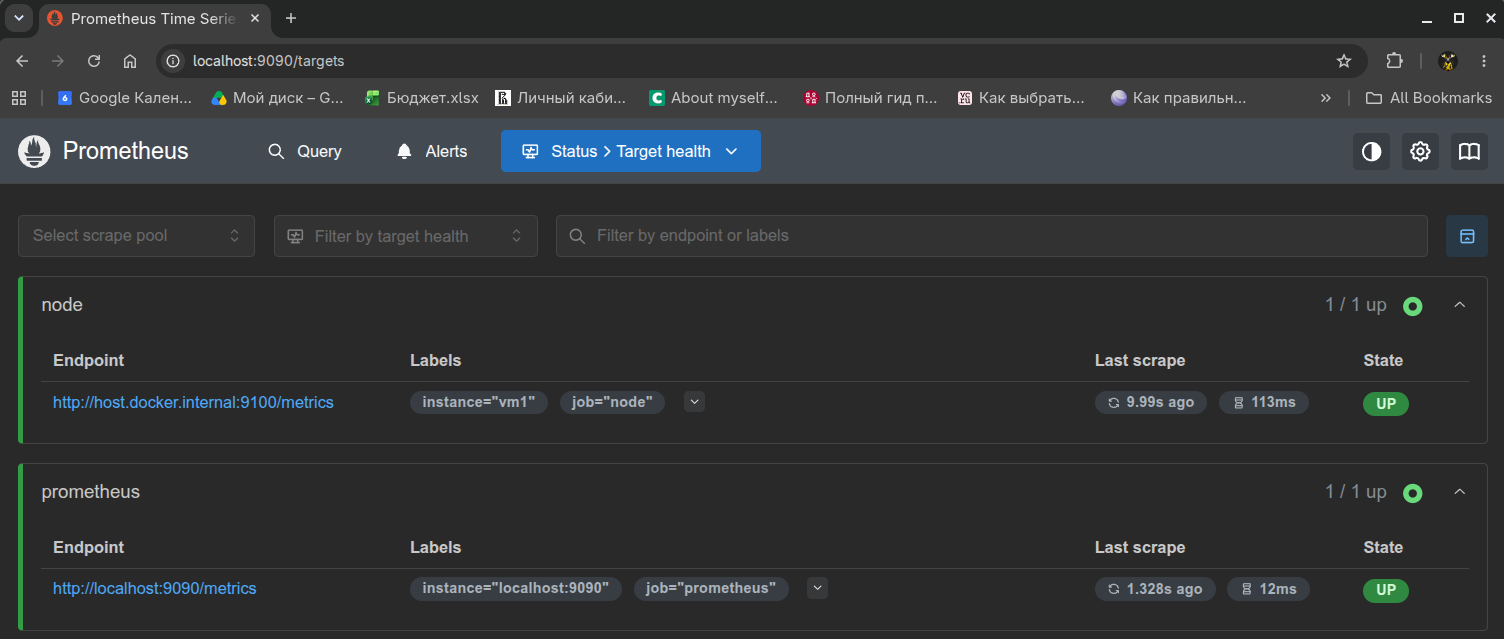

In [27]:
from IPython.display import Image, display
display(Image(filename="Scrin/Screenshot From 2026-10-06 20-56-45.png"))

## Добавляем Prometheus в Grafana

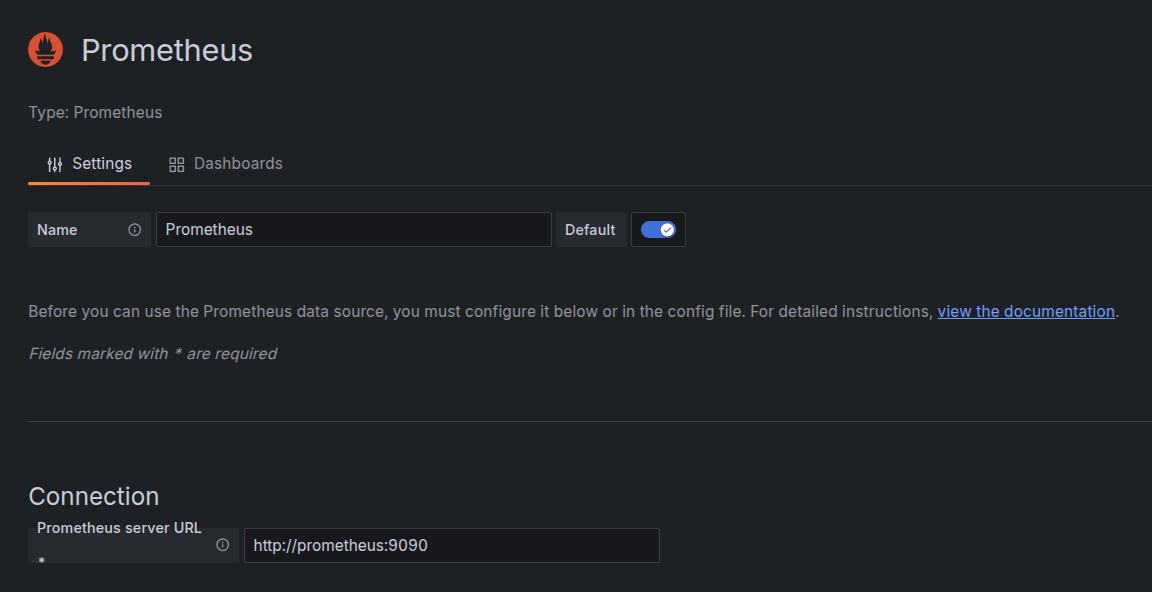

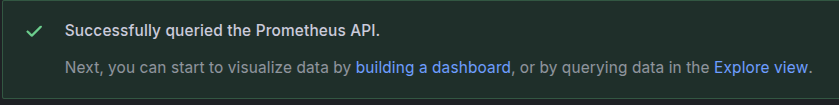

In [30]:
display(Image(filename="Scrin/Screenshot From 2026-10-06 21-06-52.png"))
display(Image(filename="Scrin/Screenshot From 2026-10-06 21-04-39.png"))

## Делаем дашборд

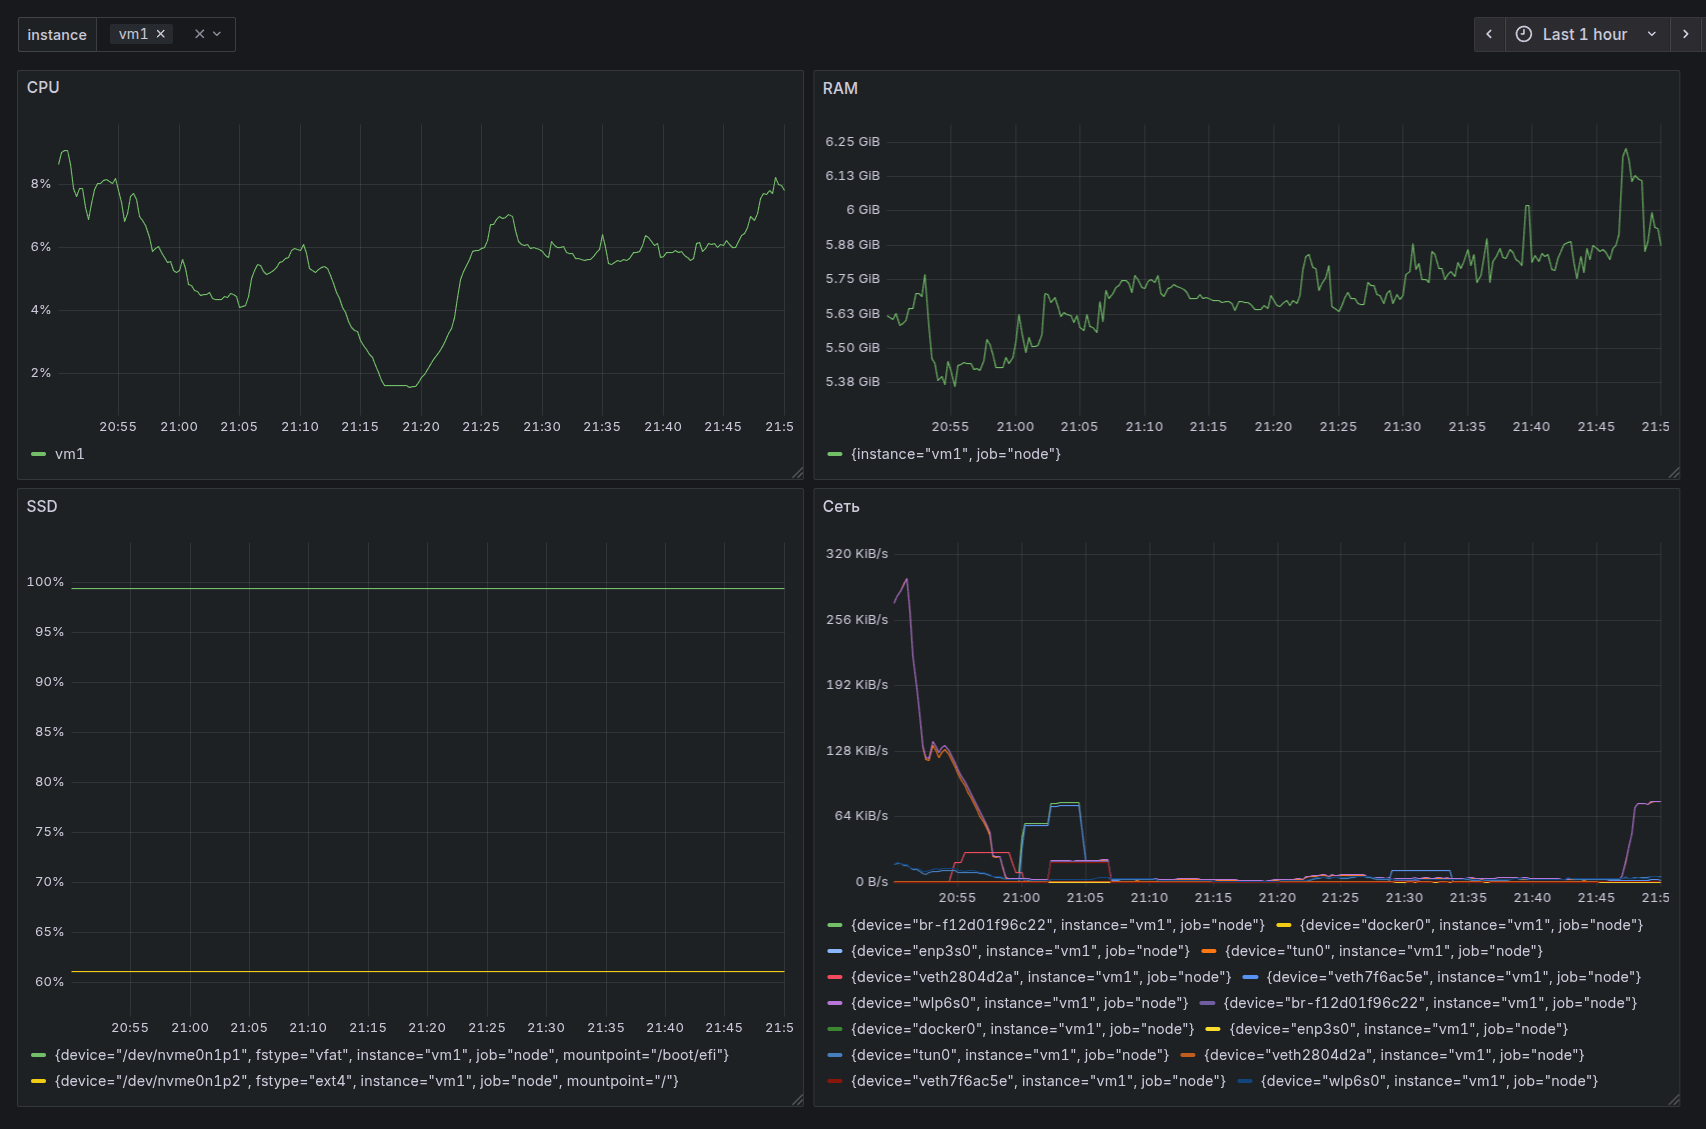

In [36]:
display(Image(filename="Scrin/Screenshot From 2026-10-06 21-50-54.png"))

### Экспорт JSON

В Графане я не нашел прям кнопки экспорта JSON, поэтому просто создал файл и скопировал всё в него и положил по пути - `monitoring/grafana/dashboard.json`

## Задание 2. Три Dockerfile для counter-backend

### Dockerfile.single


In [7]:
%%bash
set -euo pipefail
cd counter-backend
docker build -f Dockerfile.single -t counter-backend:single .

DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/



Sending build context to Docker daemon  118.8kB
Step 1/12 : FROM python:3.11.6-slim-bookworm
 ---> cc7585194810
Step 2/12 : SHELL ["/bin/sh", "-eu", "-c"]
 ---> Using cache
 ---> 6125279de642
Step 3/12 : WORKDIR /app
 ---> Using cache
 ---> 8869cf60a689
Step 4/12 : COPY pyproject.toml poetry.lock README.md ./
 ---> Using cache
 ---> 945d8a589abe
Step 5/12 : COPY src/ src/
 ---> Using cache
 ---> cb4b31d71ead
Step 6/12 : RUN python -m pip install   --no-color   --no-cache-dir   --disable-pip-version-check   --no-python-version-warning   --no-warn-script-location   --break-system-packages   --progress-bar off   poetry poetry-plugin-export setuptools wheel
 ---> Using cache
 ---> 8306826ac851
Step 7/12 : RUN mkdir -p dist   && poetry export     --without-hashes     --format constraints.txt     --output dist/constraints.txt   && poetry run     python -m pip wheel      --isolated      --requirement dist/constraints.txt      --wheel-dir dist/vendor
 ---> Using cache
 ---> 0baadb83ec5c
Step 8

In [11]:
%%bash
docker rm -f counter
docker run --detach --name counter --publish 127.0.0.1:8080:8080/tcp counter-backend:single

Error response from daemon: No such container: counter


58a291f7e46eb1f910957d05df11314a396320e708a202121192a3b7de4e6994


In [12]:
%%bash
curl -sS -D - http://127.0.0.1:8080/api/counter
echo
curl -sS -D - -X POST http://127.0.0.1:8080/api/counter
echo
docker exec counter id
docker rm -f counter

HTTP/1.1 200 OK
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 12:49:06 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 0}
HTTP/1.1 201 Created
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 12:49:06 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 1}
uid=0(root) gid=0(root) groups=0(root)
counter


### Dockerfile.multistage


In [13]:
%%bash
set -euo pipefail
cd counter-backend
docker build -f Dockerfile.multistage -t counter-backend:multistage .

DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/



Sending build context to Docker daemon  118.8kB
Step 1/16 : FROM python:3.11.6-slim-bookworm AS build
 ---> cc7585194810
Step 2/16 : SHELL ["/bin/sh", "-eu", "-c"]
 ---> Using cache
 ---> 6125279de642
Step 3/16 : WORKDIR /app
 ---> Using cache
 ---> 8869cf60a689
Step 4/16 : COPY pyproject.toml poetry.lock README.md ./
 ---> Using cache
 ---> 945d8a589abe
Step 5/16 : COPY src/ src/
 ---> Using cache
 ---> cb4b31d71ead
Step 6/16 : RUN python -m pip install   --no-color   --no-cache-dir   --disable-pip-version-check   --no-python-version-warning   --no-warn-script-location   --break-system-packages   --progress-bar off   poetry poetry-plugin-export setuptools wheel
 ---> Using cache
 ---> 8306826ac851
Step 7/16 : RUN mkdir -p dist   && poetry export     --without-hashes     --format constraints.txt     --output dist/constraints.txt   && poetry run     python -m pip wheel      --isolated      --requirement dist/constraints.txt      --wheel-dir dist/vendor
 ---> Using cache
 ---> 0baadb83ec

In [14]:
%%bash
docker rm -f counter
docker run --detach --name counter --publish 127.0.0.1:8080:8080/tcp counter-backend:multistage

Error response from daemon: No such container: counter


98f09cecc68ced86b35be03249c08d3d5798ef36574739bfbf973172c02345e3


In [15]:
%%bash
curl -sS -D - http://127.0.0.1:8080/api/counter
echo
curl -sS -D - -X POST http://127.0.0.1:8080/api/counter
echo
docker exec counter id
docker rm -f counter

HTTP/1.1 200 OK
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 12:51:58 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 0}
HTTP/1.1 201 Created
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 12:51:58 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 1}
uid=0(root) gid=0(root) groups=0(root)
counter


### Dockerfile.nonroot


In [16]:
%%bash
set -euo pipefail
cd counter-backend
docker build -f Dockerfile.nonroot -t counter-backend:nonroot .

DEPRECATED: The legacy builder is deprecated and will be removed in a future release.
            Install the buildx component to build images with BuildKit:
            https://docs.docker.com/go/buildx/



Sending build context to Docker daemon  118.8kB
Step 1/22 : FROM python:3.11.6-slim-bookworm AS build
 ---> cc7585194810
Step 2/22 : SHELL ["/bin/sh", "-eu", "-c"]
 ---> Using cache
 ---> 6125279de642
Step 3/22 : WORKDIR /app
 ---> Using cache
 ---> 8869cf60a689
Step 4/22 : COPY pyproject.toml poetry.lock README.md ./
 ---> Using cache
 ---> 945d8a589abe
Step 5/22 : COPY src/ src/
 ---> Using cache
 ---> cb4b31d71ead
Step 6/22 : RUN python -m pip install   --no-color   --no-cache-dir   --disable-pip-version-check   --no-python-version-warning   --no-warn-script-location   --break-system-packages   --progress-bar off   poetry poetry-plugin-export setuptools wheel
 ---> Using cache
 ---> 8306826ac851
Step 7/22 : RUN mkdir -p dist   && poetry export     --without-hashes     --format constraints.txt     --output dist/constraints.txt   && poetry run     python -m pip wheel      --isolated      --requirement dist/constraints.txt      --wheel-dir dist/vendor
 ---> Using cache
 ---> 0baadb83ec

Финальная стадия сначала создаёт группу и пользователя `user` (UID/GID 1001) командами `addgroup` и `adduser`, ставит пакеты от root и только потом переключается инструкцией `USER`. Дальше процесс контейнера работает уже не от root.


In [17]:
%%bash
docker rm -f counter
docker run --detach --name counter --publish 127.0.0.1:8080:8080/tcp counter-backend:nonroot

Error response from daemon: No such container: counter


8295ed53b2efaffc8f7d39eebe896404d2818f52caa94065f69e89860e23d5f5


In [18]:
%%bash
curl -sS -D - http://127.0.0.1:8080/api/counter
echo
curl -sS -D - -X POST http://127.0.0.1:8080/api/counter
echo
docker exec counter id
docker rm -f counter

HTTP/1.1 200 OK
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 13:30:28 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 0}
HTTP/1.1 201 Created
Content-Type: application/json; charset=utf-8
Content-Length: 12
Date: Wed, 07 Oct 2026 13:30:28 GMT
Server: Python/3.11 aiohttp/3.8.5

{"count": 1}
uid=1001(user) gid=1001(user) groups=1001(user),100(users)
counter


### Сравнение размеров


In [23]:
%%bash
docker image ls counter-backend --format 'table {{.Tag}}	{{.Size}}'

TAG          SIZE
nonroot      234MB
multistage   234MB
single       379MB
